# Gymnasium

Gymnasium is a project that provides an API (application programming interface) for all single agent reinforcement learning environments, with implementations of common environments: cartpole, pendulum, mountain-car, mujoco, atari, and more. This page will outline the basics of how to use **Gymnasium** including its four key functions: `make()`, `Env.reset()`, `Env.step()` and `Env.render()`.

At the core of **Gymnasium** is `Env`, a high-level python class representing a markov decision process (MDP) from reinforcement learning theory (note: this is not a perfect reconstruction, missing several components of MDPs). The class provides users the ability generate an initial state, transition / move to new states given an action and visualize the environment. Alongside Env, Wrapper are provided to help augment / modify the environment, in particular, the agent observations, rewards and actions taken.

## Initializing Environments

In [ ]:
import gymnasium as gym

env = gym.make("LunarLander-v3")

In [ ]:
import gymnasium as gym

env = gym.make("LunarLander-v3")

In [ ]:
gym.envs.registry.keys()

dict_keys(['CartPole-v0', 'CartPole-v1', 'MountainCar-v0', 'MountainCarContinuous-v0', 'Pendulum-v1', 'Acrobot-v1', 'phys2d/CartPole-v0', 'phys2d/CartPole-v1', 'phys2d/Pendulum-v0', 'LunarLander-v3', 'LunarLanderContinuous-v3', 'BipedalWalker-v3', 'BipedalWalkerHardcore-v3', 'CarRacing-v3', 'Blackjack-v1', 'FrozenLake-v1', 'FrozenLake8x8-v1', 'CliffWalking-v1', 'CliffWalkingSlippery-v1', 'Taxi-v3', 'tabular/Blackjack-v0', 'tabular/CliffWalking-v0', 'Reacher-v2', 'Reacher-v4', 'Reacher-v5', 'Pusher-v2', 'Pusher-v4', 'Pusher-v5', 'InvertedPendulum-v2', 'InvertedPendulum-v4', 'InvertedPendulum-v5', 'InvertedDoublePendulum-v2', 'InvertedDoublePendulum-v4', 'InvertedDoublePendulum-v5', 'HalfCheetah-v2', 'HalfCheetah-v3', 'HalfCheetah-v4', 'HalfCheetah-v5', 'Hopper-v2', 'Hopper-v3', 'Hopper-v4', 'Hopper-v5', 'Swimmer-v2', 'Swimmer-v3', 'Swimmer-v4', 'Swimmer-v5', 'Walker2d-v2', 'Walker2d-v3', 'Walker2d-v4', 'Walker2d-v5', 'Ant-v2', 'Ant-v3', 'Ant-v4', 'Ant-v5', 'Humanoid-v2', 'Humanoid-v3', 

## Interacting with the Environment

![image.png](attachment:image.png)

In [ ]:
import gymnasium as gym

env = gym.make("LunarLander-v3", render_mode='human')
observation, info = env.reset()

episode_over = False
while not episode_over:
    action = env.action_space.sample()
    observation, reward, terminated, truncated, info = env.step(action)
    print(reward)
    episode_over = terminated or truncated

env.close()

0.45122804782738624
-2.116213010957891
1.3429352004086865
-0.14063613524206062
-0.9940451797561423
-2.044661003687962
-1.23208449014939
-1.2620237110977541
-1.2875262693941636
-1.042241666571232
-2.565746418984729
-2.365789991087381
-2.8942866537420557
-1.8423767416447276
-3.054696328961738
-1.2403754691609652
-1.9089476122366023
-1.9069237570219002
-2.9029992236845303
1.2122786898400022
0.9284402145373292
-2.230813731084595
-0.43782442259770277
-3.3219717908339974
-1.405379914378243
-2.2739517512636667
-2.2354516045809874
-1.10774917918087
-0.7242277380426174
-1.1816168729753713
-0.7568892374739267
-1.7907258395104009
-2.6477301435291154
-3.036738299192534
-3.017013041464763
-3.162113317484254
-1.330393216909356
-1.019572329578266
-2.139341086763909
-2.757262436308024
-2.933105150696035
-3.3291932998347122
-3.2672308054559265
-2.367712812299885
-3.594715190425829
-3.456116808552308
-4.356660828662473
-1.5679857022440433
-2.4679289199207233
-3.3312298208759032
-3.1216950456113066
-2.93

## Action and observation spaces

Importantly, `Env.action_space` and `Env.observation_space` are instances of Space, a high-level python class that provides the key functions: `Space.contains()` and `Space.sample()`. Gymnasium has support for a wide range of spaces that users might need:

`Box`: describes bounded space with upper and lower limits of any n-dimensional shape.

`Discrete`: describes a discrete space where {0, 1, ..., n-1} are the possible values our observation or action can take.

`MultiBinary`: describes a binary space of any n-dimensional shape.

`MultiDiscrete`: consists of a series of Discrete action spaces with a different number of actions in each element.

`Text`: describes a string space with a minimum and maximum length.

`Dict`: describes a dictionary of simpler spaces.

`Tuple`: describes a tuple of simple spaces.

`Graph`: describes a mathematical graph (network) with interlinking nodes and edges.

`Sequence`: describes a variable length of simpler space elements.

For example usage of spaces, see their documentation along with utility functions. There are a couple of more niche spaces Graph, Sequence and Text.

In [ ]:
env.action_space

Discrete(4)

In [ ]:
env.observation_space

Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)

## Modifying the environment

In order to wrap an environment, you must first initialize a base environment. Then you can pass this environment along with (possibly optional) parameters to the wrapper’s constructor:

Gymnasium already provides many commonly used wrappers for you. Some examples:

- `TimeLimit`: Issues a truncated signal if a maximum number of timesteps has been exceeded (or the base environment has issued a truncated signal).

- `ClipAction`: Clips any action passed to step such that it lies in the base environment’s action space.

- `RescaleAction`: Applies an affine transformation to the action to linearly scale for a new low and high bound on the environment.

- `TimeAwareObservation`: Add information about the index of timestep to observation. In some cases helpful to ensure that transitions are Markov.


In [ ]:
env = gym.make("LunarLander-v3", render_mode='human')
env_wrapped = gym.wrappers.TimeLimit(env=env, max_episode_steps=20)
observation, info = env_wrapped.reset()

episode_over = False
while not episode_over:
    action = env_wrapped.action_space.sample()
    observation, reward, terminated, truncated, info = env_wrapped.step(action)
    print(reward)
    episode_over = terminated or truncated

env_wrapped.close()

1.0146664873346196
-1.1971154591128084
-1.2360038727592837
-2.0844056295569247
0.8980572472923825
-2.5510383156801013
-0.5888253472775478
-0.04816645091925692
-0.318275700191889
-2.381576693643494
-1.0121506064044354
-1.2874901482598204
-1.3064637966033956
-0.22280543075396395
0.38840335626106254
0.05467928304426664
-0.9276315631669831
0.15386745451306297
0.4812166389973538
1.8439889730991978


In [ ]:
env = gym.make("LunarLander-v3", render_mode='human')
#env_wrapped = gym.wrappers.TimeLimit(env=env, max_episode_steps=1)
observation, info = env.reset()

episode_over = False
while not episode_over:
    action = env_wrapped.action_space.sample()
    observation, reward, terminated, truncated, info = env.step(action)
    print(reward)
    print(observation)
    print(terminated)
    print(truncated)
    print(info)
    episode_over = terminated or truncated

env.close()


1.3492332136634104
[ 0.0036478   1.4242907   0.18447834  0.28427008 -0.00417427 -0.04135477
  0.          0.        ]
False
False
{}
1.4134031312002264
[ 0.00547171  1.4300876   0.18448478  0.2576396  -0.00624072 -0.04133294
  0.          0.        ]
False
False
{}
1.994812697813644
[ 0.00723143  1.4352937   0.17642687  0.23138049 -0.00668884 -0.00896322
  0.          0.        ]
False
False
{}
-0.5237742658984985
[ 0.00897465  1.440429    0.17486653  0.22823535 -0.00722796 -0.01078334
  0.          0.        ]
False
False
{}
1.5592234378558487
[ 0.01071787  1.4449642   0.17486826  0.20156287 -0.00776653 -0.01077284
  0.          0.        ]
False
False
{}
1.5035825306670745
[ 0.01246109  1.4488994   0.17486985  0.17489637 -0.00830507 -0.010772
  0.          0.        ]
False
False
{}
-1.5883502775395357
[ 1.4324570e-02  1.4528574e+00  1.8633239e-01  1.7590807e-01
 -8.2869399e-03  3.6281886e-04  0.0000000e+00  0.0000000e+00]
False
False
{}
1.4162135700921397
[ 1.6188050e-02  1.4562151e

In [ ]:
env = env_wrapped.unwrapped

## Exmaple: Training a model

In [ ]:
from collections import defaultdict
import gymnasium as gym
import numpy as np


class BlackjackAgent:
    def __init__(
        self,
        env: gym.Env,
        learning_rate: float,
        initial_epsilon: float,
        epsilon_decay: float,
        final_epsilon: float,
        discount_factor: float = 0.95,
    ):
        """Initialize a Reinforcement Learning agent with an empty dictionary
        of state-action values (q_values), a learning rate and an epsilon.

        Args:
            env: The training environment
            learning_rate: The learning rate
            initial_epsilon: The initial epsilon value
            epsilon_decay: The decay for epsilon
            final_epsilon: The final epsilon value
            discount_factor: The discount factor for computing the Q-value
        """
        self.env = env
        self.q_values = defaultdict(lambda: np.zeros(env.action_space.n))

        self.lr = learning_rate
        self.discount_factor = discount_factor

        self.epsilon = initial_epsilon
        self.epsilon_decay = epsilon_decay
        self.final_epsilon = final_epsilon

        self.training_error = []

    def get_action(self, obs: tuple[int, int, bool]) -> int:
        """
        Returns the best action with probability (1 - epsilon)
        otherwise a random action with probability epsilon to ensure exploration.
        """
        # with probability epsilon return a random action to explore the environment
        if np.random.random() < self.epsilon:
            return self.env.action_space.sample()
        # with probability (1 - epsilon) act greedily (exploit)
        else:
            return int(np.argmax(self.q_values[obs]))

    def update(
        self,
        obs: tuple[int, int, bool],
        action: int,
        reward: float,
        terminated: bool,
        next_obs: tuple[int, int, bool],
    ):
        """Updates the Q-value of an action."""
        future_q_value = (not terminated) * np.max(self.q_values[next_obs])
        temporal_difference = (
            reward + self.discount_factor * future_q_value - self.q_values[obs][action]
        )

        self.q_values[obs][action] = (
            self.q_values[obs][action] + self.lr * temporal_difference
        )
        self.training_error.append(temporal_difference)

    def decay_epsilon(self):
        self.epsilon = max(self.final_epsilon, self.epsilon - self.epsilon_decay)

In [ ]:
learning_rate = 0.01
n_episodes = 100_000
start_epsilon = 1.0
epsilon_decay = start_epsilon / (n_episodes / 2)  # reduce the exploration over time
final_epsilon = 0.1

env = gym.make('FrozenLake-v1', desc=None, map_name="4x4", is_slippery=True)
env = gym.wrappers.RecordEpisodeStatistics(env, buffer_length=n_episodes)

agent = BlackjackAgent(
    env=env,
    learning_rate=learning_rate,
    initial_epsilon=start_epsilon,
    epsilon_decay=epsilon_decay,
    final_epsilon=final_epsilon,
)

In [ ]:
from tqdm import tqdm

for episode in tqdm(range(n_episodes)):
    obs, info = env.reset()
    done = False

    # play one episode
    while not done:
        action = agent.get_action(obs)
        next_obs, reward, terminated, truncated, info = env.step(action)

        # update the agent
        agent.update(obs, action, reward, terminated, next_obs)

        # update if the environment is done and the current obs
        done = terminated or truncated
        obs = next_obs

    agent.decay_epsilon()

100%|██████████| 100000/100000 [01:17<00:00, 1296.05it/s]


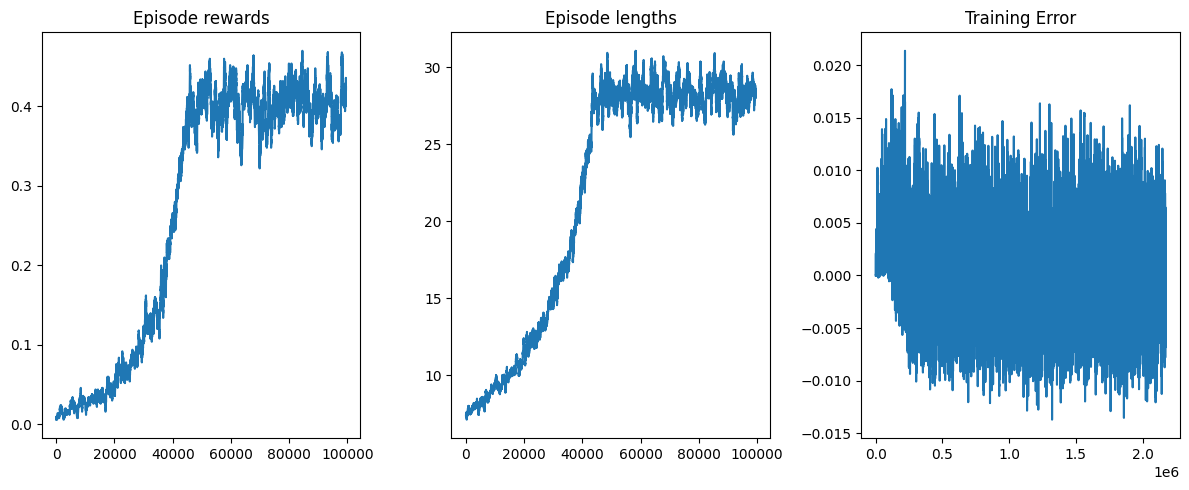

In [ ]:
from matplotlib import pyplot as plt

def get_moving_avgs(arr, window, convolution_mode):
    return np.convolve(
        np.array(arr).flatten(),
        np.ones(window),
        mode=convolution_mode
    ) / window

# Smooth over a 500 episode window
rolling_length = 500
fig, axs = plt.subplots(ncols=3, figsize=(12, 5))

axs[0].set_title("Episode rewards")
reward_moving_average = get_moving_avgs(
    env.return_queue,
    rolling_length,
    "valid"
)
axs[0].plot(range(len(reward_moving_average)), reward_moving_average)

axs[1].set_title("Episode lengths")
length_moving_average = get_moving_avgs(
    env.length_queue,
    rolling_length,
    "valid"
)
axs[1].plot(range(len(length_moving_average)), length_moving_average)

axs[2].set_title("Training Error")
training_error_moving_average = get_moving_avgs(
    agent.training_error,
    rolling_length,
    "same"
)
axs[2].plot(range(len(training_error_moving_average)), training_error_moving_average)
plt.tight_layout()
plt.show()

In [ ]:
env = gym.make('FrozenLake-v1', desc=None, map_name="4x4", is_slippery=True, render_mode='human')

obs, info = env.reset()
done = False

# play one episode
while not done:
    action = agent.get_action(obs)
    next_obs, reward, terminated, truncated, info = env.step(action)

    # update if the environment is done and the current obs
    done = terminated or truncated
    obs = next_obs
env.close()

## Create a Custom Environment

In [ ]:
from typing import Optional
import numpy as np
import gymnasium as gym


class GridWorldEnv(gym.Env):

    def __init__(self, size: int = 5):
        # The size of the square grid
        self.size = size

        # Define the agent and target location; randomly chosen in `reset` and updated in `step`
        self._agent_location = np.array([-1, -1], dtype=np.int32)
        self._target_location = np.array([-1, -1], dtype=np.int32)

        # Observations are dictionaries with the agent's and the target's location.
        # Each location is encoded as an element of {0, ..., `size`-1}^2
        self.observation_space = gym.spaces.Dict(
            {
                "agent": gym.spaces.Box(0, size - 1, shape=(2,), dtype=int),
                "target": gym.spaces.Box(0, size - 1, shape=(2,), dtype=int),
            }
        )

        # We have 4 actions, corresponding to "right", "up", "left", "down"
        self.action_space = gym.spaces.Discrete(4)
        # Dictionary maps the abstract actions to the directions on the grid
        self._action_to_direction = {
            0: np.array([1, 0]),  # right
            1: np.array([0, 1]),  # up
            2: np.array([-1, 0]),  # left
            3: np.array([0, -1]),  # down
        }

    def _get_obs(self):
        return {"agent": self._agent_location, "target": self._target_location}

    def _get_info(self):
        return {
            "distance": np.linalg.norm(
                self._agent_location - self._target_location, ord=1
            )
        }

    def reset(self, seed: Optional[int] = None, options: Optional[dict] = None):
        # We need the following line to seed self.np_random
        super().reset(seed=seed)

        # Choose the agent's location uniformly at random
        self._agent_location = self.np_random.integers(0, self.size, size=2, dtype=int)

        # We will sample the target's location randomly until it does not coincide with the agent's location
        self._target_location = self._agent_location
        while np.array_equal(self._target_location, self._agent_location):
            self._target_location = self.np_random.integers(
                0, self.size, size=2, dtype=int
            )

        observation = self._get_obs()
        info = self._get_info()

        return observation, info

    def step(self, action):
        # Map the action (element of {0,1,2,3}) to the direction we walk in
        direction = self._action_to_direction[action]
        # We use `np.clip` to make sure we don't leave the grid bounds
        self._agent_location = np.clip(
            self._agent_location + direction, 0, self.size - 1
        )

        # An environment is completed if and only if the agent has reached the target
        terminated = np.array_equal(self._agent_location, self._target_location)
        truncated = False
        reward = 1 if terminated else 0  # the agent is only reached at the end of the episode
        observation = self._get_obs()
        info = self._get_info()

        return observation, reward, terminated, truncated, info

    def render(self):
      pass

gym.register(
    id="gymnasium_env/GridWorld-v0",
    entry_point=GridWorldEnv,
)

/home/aliakbar/miniconda3/envs/rl/lib/python3.10/site-packages/gymnasium/envs/registration.py:644: UserWarning: WARN: Overriding environment gymnasium_env/GridWorld-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")


In [ ]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

class PendulamWind(gym.Env):
  def __init__(self):
    self.wind_discount = -1
    self.point1 = gym.spaces.Box(-10, 10, shape=(1,))
    self.point2_x = gym.spaces.Box(-10, 10, shape=(1,))
    self.point2_y = gym.spaces.Box(0, 1, shape=(1,))
    self.movement = 0

    self.action_space = gym.space.Discrete(2)
    self.action_map = {
        0: np.array((1,)), #right
        1: np.array((-1,)) #left
    }

  def reset(self):
    self.point1 = np.clip(np.random.randint(-10, 10),0 , 10)
    self.point2_x = self.point1
    self.point2_y = np.array([1])

    return np.array(self.point1, self.point2_x, self.poin2_y), {}


  def info(self):
    return {}

  def step(self, action):
    _action = self.action_map[action]
    if self.movemnet == 1:
      self.point1 = self.movment + self.action
      if np.random.rand() < 0.5:
        self.point2_x = self.movment + self.action
        if np.np_array(self.movement, self.action):
          point2_y = self.point2_y - 0.1
          return (self.point1, self.point2_x, self.point2_y), 1, False, False, self.info()
        else:
          point2_y = self.point2_y + 0.1
          return (self.point1, self.point2_x, self.point2_y), -1, False, False, self.info()
    elif self.movement == 2:
      self.point1 = self.movment + self.action
      if np.random.rand() < 0.5:
        self.point2_x = self.movment + self.action
        if np.np_array(self.movement, self.action):
          point2_y = self.point2_y + 0.1
          return (self.point1, self.point2_x, self.point2_y), 1, False, False, self.info()
        else:
          point2_y = self.point2_y - 0.1
          return (self.point1, self.point2_x, self.point2_y), -1, False, False, self.info()
    return self.point_1 + action, 10, False, False, self.info()


  def render(self):
    pass

## Recording Agents

During training or when evaluating an agent, it may be interesting to record agent behaviour over an episode and log the total reward accumulated. This can be achieved through two wrappers: `RecordEpisodeStatistics` and `RecordVideo`, the first tracks episode data such as the total rewards, episode length and time taken and the second generates mp4 videos of the agents using the environment renderings.

We show how to apply these wrappers for two types of problems; the first for recording data for every episode (normally evaluation) and second for recording data periodically (for normal training).